# **California Landscape Metrics Analysis**

### A Natural Language Science Notebook

This notebook demonstrates **ARGUS** (Agentic Researcher Guide for Unified Science) extended via **MCP (Model Context Protocol)**. The `%%mcp` cell below registers an MCP server that exposes search and zonal-statistics tools over **California Landscape Metrics (CLM)** — a collection of nearly 200 high-resolution geospatial layers developed by an interagency science team for the California Wildfire and Forest Resilience Task Force to support land-manager planning of forest and shrubland resilience. Each analytical step is then expressed as a plain English `%%ask` prompt.

**What this notebook does (all queries hit CLM layers via MCP):**
1. Computes the average **carbon turnover time** in Los Angeles County
2. Finds the maximum **annual burn probability** in San Diego County
3. Visualizes the carbon turnover layer on a map
4. Shows the value distribution across San Diego
5. Ranks the top 5 California counties by mean carbon turnover time


####   **Choose your language model**
  
  Argus is model-agnostic — you can plug in any of the major LLM providers and Argus will work. Pick whichever you have an API key for. To switch, comment out the active `LLM = {...}` block and uncomment the one you want.

  **This notebook defaults to GLM-5 via the National Research Platform** (free for NRP users, strong on scientific tool use). If you don't have NRP
  access, swap in OpenAI, Anthropic, or Google — they all work.

  **Before you run the cell: save your API key as a Colab Secret**

  Argus reads your API key from a Colab Secret, not from the notebook itself — that keeps the key out of your saved file and out of anyone you share the
  notebook with.

  1. Click the 🔑 key icon in the left sidebar (**Secrets**).
  2. Click **+ Add new secret**.
  3. Set the **Name** to match the `api_key_env` value in your `LLM` block:
     - `NRP_API_KEY` for GLM-5 on NRP
     - `OPENAI_API_KEY` for GPT-5.5
     - `ANTHROPIC_API_KEY` for Claude Sonnet/Opus
     - `GOOGLE_API_KEY` for Gemini

  4. Paste your key into the **Value** field.
  5. Toggle **Notebook access** on for this notebook.

  If the key isn't set (or notebook access is off), Argus will fail with an authentication error when it tries to call the model.

  ### Supported models

  | Provider | Models |
  |---|---|
  | OpenAI | GPT-5.5, GPT-5.4 |
  | Anthropic | Claude Opus 4.7, Opus 4.6 |
  | Google | Gemini 3.5 Flash |
  | Z.ai | GLM-5, GLM-5.1 |
  | Moonshot | Kimi-K2.6 |
  | MiniMax | MiniMax-M2.7 |
  | DeepSeek | DeepSeek-V4 Flash |

  Any model in this list should run Argus notebooks correctly. The four pre-configured blocks below are starter templates; for the others, follow the
  same `LLM = {...}` pattern with the right `model` and `api_key_env`.

In [ ]:
  # Use GLM-5 from National Research Platform
  LLM = {
      "model": "glm-5",
      "url": "https://ellm.nrp-nautilus.io/v1",
      "api_key_env": "NRP_API_KEY",
  }

  # Use GPT-5.5 from OpenAI
  # LLM = {
  #     "model": "gpt-5.5",
  #     "api_key_env": "OPENAI_API_KEY",
  # }

  # Use Claude Sonnet 4.6 from Anthropic
  # LLM = {
  #     "model": "claude-sonnet-4-6",
  #     "api_key_env": "ANTHROPIC_API_KEY",
  #     "flavor": "anthropic",
  # }

  # Use Gemini 3.5 Flash from Google
  # LLM = {
  #     "model": "gemini-3.5-flash",
  #     "api_key_env": "GOOGLE_API_KEY",
  #     "flavor": "gemini",
  # }


#### **Install Argus from GitHub Repo**

In [ ]:
import urllib.request
exec(urllib.request.urlopen(
    'https://raw.githubusercontent.com/klinucsd/sage/main/argus_colab/install.py'
).read().decode(), globals())

ARGUS bootstrap starting...
  ✓ Wrote LLM config to /root/.deepagents/config.toml (added default params for 1 ChatOpenAI provider(s))
  ✓ Loaded ZAI_API_KEY from Colab Secrets
  · Installing ARGUS dependencies (~30–90 s the first time)...
  ✓ ARGUS dependencies installed
  ✓ Downloaded sage_magic.py + sage_kernel_backend.py from main
  ✓ Installed 7 core skill(s) into /root/.deepagents/agent/skills: ndp-search, sage-bbox-map, sage-dropdown, sage-metrics, skillsmp, us-counties, us-states

ARGUS ready — %%ask, %%mcp, %%skill are registered.
  Provider: llm  ·  Model: llm:glm-5


In [ ]:
%reset

**Sage reset.** Output folder cleared, history cleared.

In [ ]:
%%mcp
{
    "mcpServers": {
      "wenokn": {"url": "https://wenokn.fastmcp.app/mcp"}
    }
}

In [ ]:
%%ask
What is the average carbon turnover time in Los Angeles?

Let me search for the carbon turnover time dataset and then compute the average for Los Angeles.

Found the dataset. Now computing zonal statistics for Los Angeles County.

Here are the results for **Aboveground Carbon Turnover Time in Los Angeles County** (source: *Aboveground Carbon Turnover Time and Residency Time* dataset):

| Statistic | Value |
|-----------|-------|
| **Average (mean)** | **19.84 years** |
| Minimum | 0.0 years |
| Maximum | 200.0 years |
| Standard deviation | 9.74 years |

**Interpretation** : The average aboveground carbon turnover time across Los Angeles County is approximately **19.8 years** . This represents the average lifetime of aboveground live and dead carbon. The relatively moderate turnover time suggests that much of the carbon in LA County resides in relatively labile pools (e.g., live or dead leaves, herbaceous vegetation) rather than highly stable pools like large trees. The high standard deviation (9.7 years) and the wide range (0–200 years) indicate significant spatial variability, with some areas (likely forested mountain regions) storing carbon in much more stable pools.

In [ ]:
%%ask
Find the maximum annual burn probability in San Diego county

Let me search for a burn probability dataset first.

Found the Annual Burn Probability dataset. Now I'll compute zonal statistics for San Diego County.

Here are the **Annual Burn Probability** statistics for San Diego County:

| Statistic | Value |
|-----------|-------|
| **Maximum** | **0.0974 (≈ 9.74%)** |
| Mean | 0.0227 (≈ 2.27%) |
| Minimum | 0.0000 |
| Standard deviation | 0.0252 |

**Interpretation** : The maximum annual burn probability in San Diego County is **~9.7%** , meaning the pixel with the highest wildfire likelihood has roughly a 1-in-10 chance of burning in any given fire season. The county-wide average is much lower at ~2.3%, with a standard deviation of ~2.5%, indicating significant spatial variability — the highest-risk areas are concentrated in specific fuel- and topography-driven zones (likely in the backcountry and wildland-urban interface), while much of the county has near-zero probability.

In [ ]:
%%ask
Show me a map of the carbon turnover dataset

Creating the WMS layer file for the carbon turnover time dataset.

Here's the map of the **Aboveground Carbon Turnover Time** dataset for California:

**About this layer** : This shows the average lifetime of aboveground live and dead carbon (in years). Darker/warmer tones indicate longer turnover times, meaning carbon is stored in more stable pools like large trees. Lighter tones indicate shorter turnover times, where carbon resides in more labile pools like leaves and herbaceous vegetation. The dataset covers the full state of California.

Now let me create a histogram to visualize the distribution.

Here's the distribution of **Aboveground Carbon Turnover Time** for San Diego County:


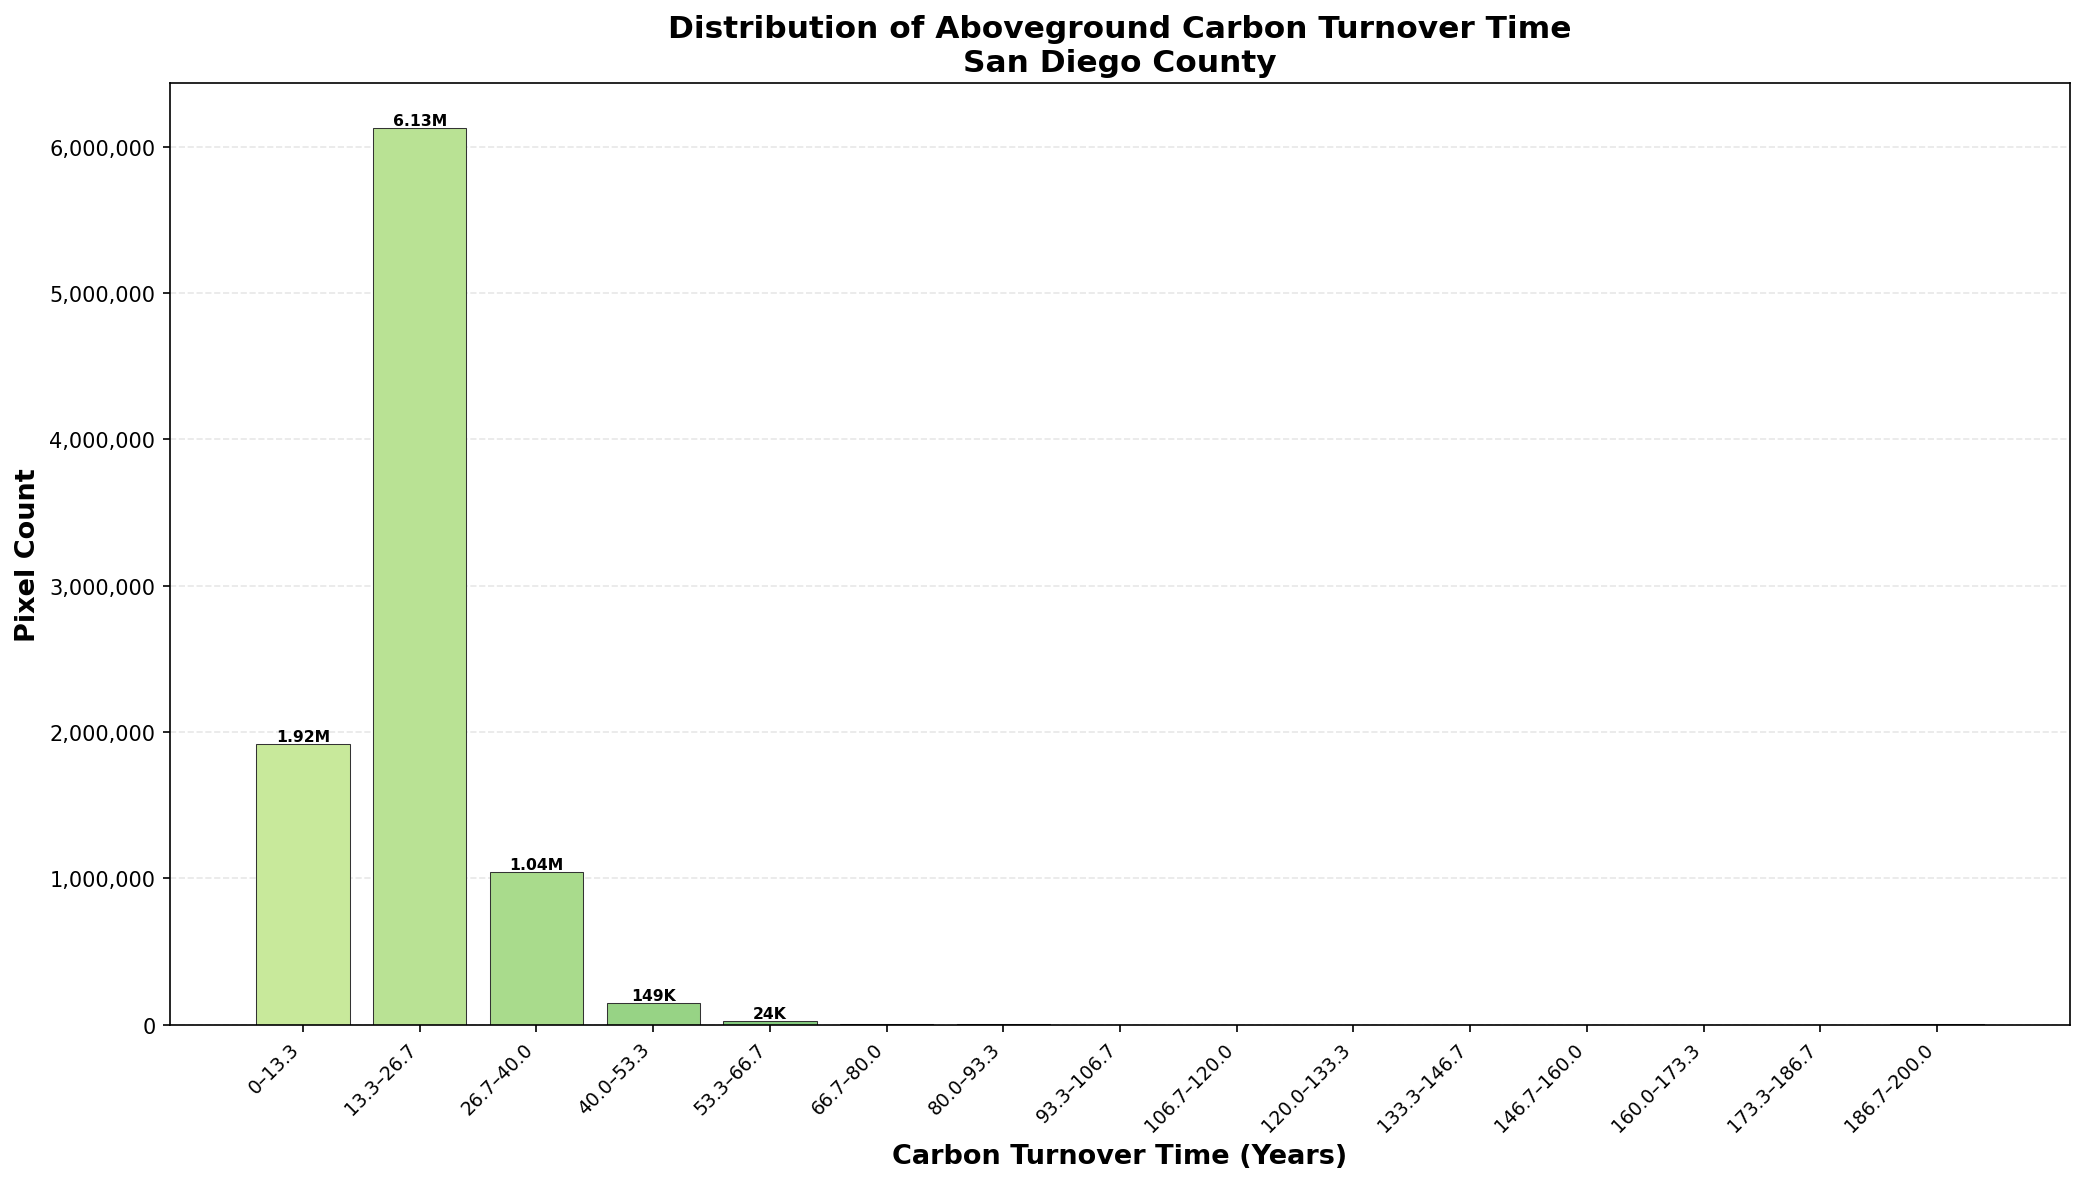

**Key findings:**

| Bin (Years) | Pixel Count | % of Total |
|---|---|---|
| **13.3 – 26.7** | **6,128,846** | **65.8%** |
| 0.0 – 13.3 | 1,917,691 | 20.6% |
| 26.7 – 40.0 | 1,041,086 | 11.2% |
| 40.0 – 53.3 | 148,935 | 1.6% |
| 53.3+ | 30,100 | 0.3% |

**Interpretation** : The distribution is strongly right-skewed. The vast majority of San Diego County (~**86%** of pixels) has a carbon turnover time under 27 years, indicating that most of the county's aboveground carbon resides in relatively labile pools (grasses, shrubs, small vegetation). Only a small fraction (~2%) exceeds 40 years, likely corresponding to mature forest stands in the county's mountainous interior. The long tail extends up to 200 years, representing highly stable carbon pools in old-growth or large-tree-dominated areas.

In [ ]:
%%ask
Show me the data distribution for San Diego

Computing mean carbon turnover time for all California counties.

The API returned a 404 — let me retry the zonal stats call without the filter to process all counties.

Now let me create a chart for the top 5 counties.


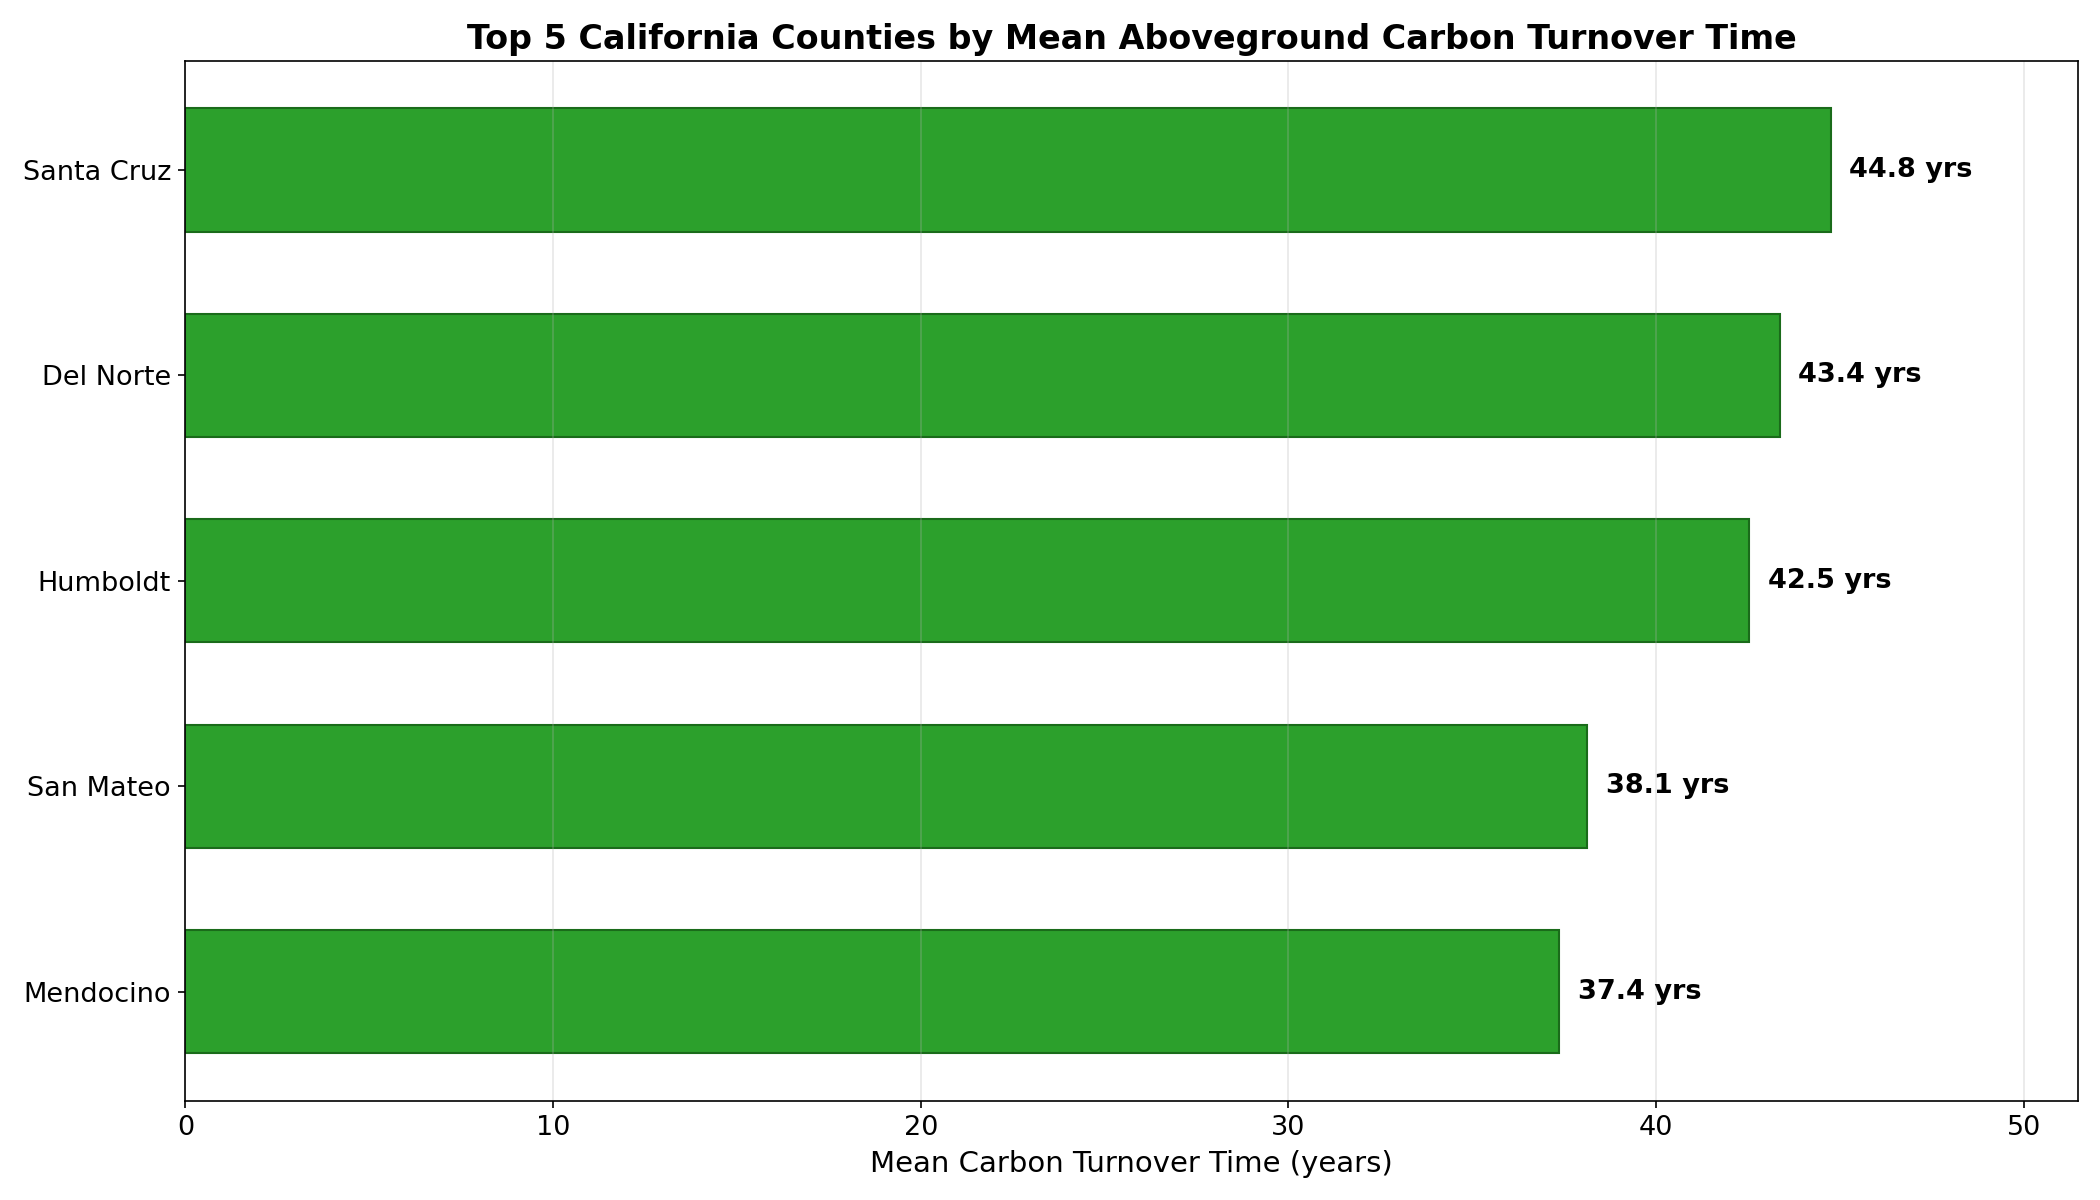

Here are the **top 5 California counties** ranked by mean aboveground carbon turnover time:

| Rank | County | Mean Turnover Time (years) |
|------|--------|---------------------------|
| 1 | **Santa Cruz** | **44.8** |
| 2 | **Del Norte** | **43.4** |
| 3 | **Humboldt** | **42.5** |
| 4 | **San Mateo** | **38.1** |
| 5 | **Mendocino** | **37.4** |

**Insights:**

- All five counties are coastal or near-coastal, dominated by **redwood, mixed conifer, and temperate rainforest** ecosystems — forests with large, long-lived trees that store carbon for decades.
- **Santa Cruz** leads at ~44.8 years, reflecting its extensive coast redwood forests where individual trees can sequester carbon for centuries.
- **Del Norte** and **Humboldt** follow closely — home to some of the most productive old-growth forests in the state.
- For comparison, **Los Angeles** (19.8 years) and **San Diego** (19.2 years) rank mid-pack, while the lowest-turnover counties are agricultural/urban — **Kings** (6.2 yrs), **Sacramento** (8.1 yrs), and **Merced** (8.4 yrs).
- All 58 counties were processed successfully in ~40 seconds.

In [ ]:
%%ask
Rank the top 5 counties by mean carbon turnover time.